In [5]:
# ==========================================
# Machine Learning Assignment - Step 2
# Dataset: NPHA Doctor Visits
# ==========================================

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

# ==========================================
# LOAD DATASET
# ==========================================

downloads_folder = os.path.expanduser("~/Downloads")
file_path = os.path.join(downloads_folder, "NPHA-doctor-visits.csv")

if not os.path.exists(file_path):
    print("Dataset not found.")
    print("\nAvailable CSV files in Downloads:\n")

    for file in os.listdir(downloads_folder):
        if file.endswith(".csv"):
            print(file)

    raise FileNotFoundError(
        "Update the filename in file_path with the correct CSV name."
    )

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

df.replace(-1, np.nan, inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

# ==========================================
# DISPLAY COLUMNS
# ==========================================

print("\nColumns:")
print(df.columns.tolist())

# ==========================================
# TARGET COLUMN
# ==========================================

target_column = "Number of Doctors Visited"

if target_column not in df.columns:
    print("\nTarget column not found.")
    print("Available columns are:")
    print(df.columns.tolist())
    raise ValueError(
        "Update target_column with the correct name."
    )

X = df.drop(target_column, axis=1)
y = df[target_column]

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# MODELS
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

# ==========================================
# MODEL EVALUATION
# ==========================================

results = []

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

for name, model in models.items():

    print(f"\nTraining {name} ...")

    if name in ["Logistic Regression", "KNN"]:

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    try:
        auc = roc_auc_score(
            y_test_bin,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )
    except:
        auc = np.nan

    results.append([
        name,
        accuracy,
        auc,
        precision,
        recall,
        f1,
        mcc
    ])

# ==========================================
# RESULT TABLE
# ==========================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "AUC",
        "Precision",
        "Recall",
        "F1 Score",
        "MCC"
    ]
)

print("\n")
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(results_df.round(4))

# ==========================================
# SAVE RESULTS
# ==========================================

results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

print(
    "\nResults saved as 'model_comparison_results.csv'"
)

Dataset Loaded Successfully
Shape: (714, 15)

Columns:
['Number of Doctors Visited', 'Age', 'Phyiscal Health', 'Mental Health', 'Dental Health', 'Employment', 'Stress Keeps Patient from Sleeping', 'Medication Keeps Patient from Sleeping', 'Pain Keeps Patient from Sleeping', 'Bathroom Needs Keeps Patient from Sleeping', 'Uknown Keeps Patient from Sleeping', 'Trouble Sleeping', 'Prescription Sleep Medication', 'Race', 'Gender']

Training Logistic Regression ...

Training Decision Tree ...

Training KNN ...

Training Naive Bayes ...

Training Random Forest ...


MODEL COMPARISON
                 Model  Accuracy     AUC  Precision  Recall  F1 Score     MCC
0  Logistic Regression    0.5524  0.6161     0.4672  0.5524    0.4487  0.1547
1        Decision Tree    0.3566  0.4630     0.3629  0.3566    0.3590 -0.0585
2                  KNN    0.4965  0.5399     0.4854  0.4965    0.4683  0.1083
3          Naive Bayes    0.2937  0.6217     0.4633  0.2937    0.2510  0.1427
4        Random Forest    0

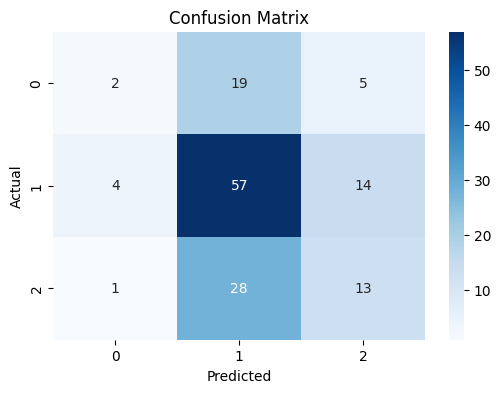

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()